## Image Denoising via Quantum Reservoir Computing



In [5]:
import random
import numpy as np

SEED = 42  # Seed não especificada no paper

random.seed(SEED)
np.random.seed(SEED)

### Dataset setup
"For the setup, we selected the first 1000 training images and 200 test images"

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train_subset_normalized = X_train[:1000].astype(np.float32) / 255.0
X_test_subset_normalized  = X_test[:200].astype(np.float32) / 255.0

y_train_subset = y_train[:1000]
y_test_subset  = y_test[:200]


### Noise dataset
"Noisy datasets were synthesized by applying multiplicative speckle noise, modeled as $I˜ = I · (1 + σ · \mathcal{N}(0, 1))$, with $\sigma = 0.7$, cut to [0,1]"

Note: Cut, not normalized

In [16]:
def apply_noise(X: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    """I˜ = clip(I · (1 + σ · N(0,1)), 0, 1). X must be float32 in [0,1]."""
    rng = np.random.default_rng(seed)
    eps = rng.normal(0, sigma, size=X.shape).astype(np.float32)
    return np.clip(X * (1 + eps), 0.0, 1.0)

In [8]:
SIGMA = 0.7
X_train_noisy = apply_noise(X_train_subset_normalized, sigma=SIGMA, seed=SEED)
X_test_noisy  = apply_noise(X_test_subset_normalized, sigma=SIGMA, seed=SEED)

### Visualize Clean vs Noisy

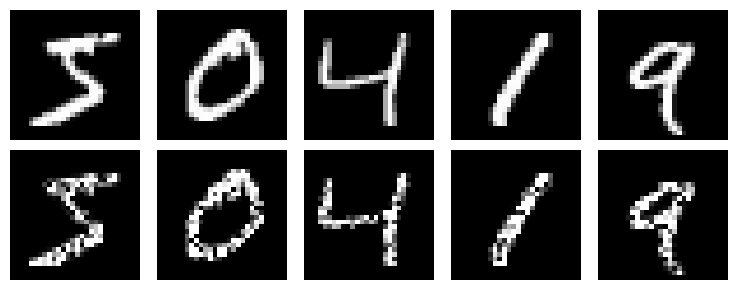

In [12]:
import matplotlib.pyplot as plt

n = 5
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

for col in range(n):
    axes[0, col].imshow(X_train_subset_normalized[col], cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_train_noisy[col],             cmap="gray", vmin=0, vmax=1)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("clean", fontsize=9)
axes[1, 0].set_ylabel("noisy", fontsize=9)
plt.tight_layout()
plt.show()

### PCA

"PCA identifies an optimal orthogonal basis ${u_1, ... , u_M }$ for the clean training data by finding the directions of maximal variance. The transformation projects the high-dimensional noisy vector $y_i$ onto the subspace spanned by the first $d ≪ M$ principal components"

In [17]:
from sklearn.decomposition import PCA

N_COMPONENTS = 18 # Máximo usado no paper

X_train_flat = X_train_subset_normalized.reshape(X_train_noisy.shape[0], -1)
X_test_flat  = X_test_subset_normalized.reshape(X_test_noisy.shape[0], -1)

pca = PCA(n_components=N_COMPONENTS)
pca.fit(X_train_flat)

explained = pca.explained_variance_ratio_
print(f"Explained variance per component: {np.round(explained, 4)}")
print(f"Cumulative explained variance ({N_COMPONENTS} PCs): {explained.sum():.4f}")

Explained variance per component: [0.0993 0.0776 0.0684 0.0543 0.0487 0.0454 0.0351 0.0303 0.0286 0.0216
 0.0206 0.0187 0.0182 0.0179 0.0164 0.0147 0.013  0.0125]
Cumulative explained variance (18 PCs): 0.6411


Projetar as versões ruidosas nos eixos do PCA

In [15]:
X_train_noisy_flat = X_train_noisy.reshape(X_train_noisy.shape[0], -1)
X_test_noisy_flat  = X_test_noisy.reshape(X_test_noisy.shape[0], -1)

X_train_noisy_pca = pca.transform(X_train_noisy_flat)  # (1000, 18)
X_test_noisy_pca  = pca.transform(X_test_noisy_flat)   # (200, 18)

print(f"Train projected: {X_train_noisy_pca.shape}")
print(f"Test  projected: {X_test_noisy_pca.shape}")

Train projected: (1000, 18)
Test  projected: (200, 18)
